In [ ]:
# This code is provided solely as supplementary material for the anonymized review of
# CVPR 2025 submission 13893
#
# It is intended exclusively for the purpose of verifying the reproducibility of the
# results reported in the submission during the double-blind peer review process.
#
# Distribution, reproduction, modification, or any other use beyond the CVPR 2025
# review process is strictly prohibited without prior written permission from the
# copyright holder.
#
# All intellectual property rights are reserved by the copyright owner.
# No license is granted. Provided "as is" without warranty of any kind, express or implied,
# including but not limited to warranties of merchantability, fitness for a particular purpose, # or non-infringement.
#
# For the anonymized review process only.

In [1]:
import os;
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "garbage_collection_threshold:0.5"
import io, random, torch, einops, datasets, fastprogress, PIL.Image, glob
import IPython.display, numpy as np, matplotlib.pyplot as plt
from copy import deepcopy
from types import SimpleNamespace
from timm.optim import Adan
from torchvision.transforms.v2.functional import to_pil_image, pil_to_tensor
from torchmetrics.classification import JaccardIndex
from torchvision.transforms.v2 import Compose, Resize, RandomCrop, RandomHorizontalFlip
from local import MSTransformer2D
from remote import RemoteModel
from fused import FusedModel

In [2]:
device = 'cuda'
dataset = datasets.DatasetDict({
    'train': datasets.load_from_disk("bdd100k_train", split='train'),
    'validation': datasets.load_from_disk("bdd500_pl_f14",split='validation')
})

Resolving data files:   0%|          | 0/215 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/215 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/190 [00:00<?, ?it/s]

In [3]:
config = SimpleNamespace()
config.epochs = 10
config.batch_size = 1
config.total_steps = config.epochs * (dataset['train'].num_rows // config.batch_size)
config.num_classes = 19
config.aspect = 1.74
config.local_size = 480
config.remote_size = 720
config.compression_level = 'near_lossless'
config.min_delay = 0
config.max_delay = 5
config.ips = 32
config.ops = 8
config.drop_path = 0.1
config.max_lr = 1e-4
config.min_lr = 1e-8
config.lr_pow = 2
config.num_workers = 8
config.save_checkpoint_name = f'checkpoint_mixed_res.pth'
config.idx_eval_frame = 14

In [4]:
model = FusedModel()

local_checkpoint = torch.load("local.r480_15e.pth",weights_only=False, map_location='cpu')
remote_checkpoint = torch.load("bdd100k_fully_remote_0_5.pth", weights_only=False, map_location='cpu')
model.local_model.load_state_dict(local_checkpoint['state_dict'])
model.remote_model.load_state_dict(remote_checkpoint['remote_state_dict'])

model.to(device);

# set drop path
for m in model.modules():
    if hasattr(m, "drop_path"):
        m.drop_path = config.drop_path

for p in [*model.remote_model.image_model.parameters(),*model.remote_model.vit3d.parameters(),]:
    p.requires_grad_(False)

learnable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = Adan(learnable_params, lr=1.0, caution=True)

def rc_sched(i_step, config):
    t = i_step / config.total_steps
    return (config.max_lr - config.min_lr) * (1 - ((np.cos(np.pi*t))**(2*config.lr_pow))) + config.min_lr

schedule = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda i_step: rc_sched(i_step, config)
)
print(sum(p.numel() for p in model.parameters())/1e6)

74.638049


In [5]:
def get_epoch_size(epoch):
    idx = min(epoch, len(config.progressive_sizes)-1)
    return config.progressive_sizes[idx]

def collate_fn(batch):
    h = config.remote_size
    w = config.aspect*h
    h = int(config.ips*(h//config.ips));
    w = int(config.ips*(w//config.ips));

    scale = 1+0.5*torch.rand(1).item()
    hr = int(h*scale)
    wr = int(w*scale)

    hL = config.local_size
    wL = config.aspect*hL
    hL = int(config.ips*(hL//config.ips));
    wL = int(config.ips*(wL//config.ips));

    delay = np.random.choice(range(config.min_delay,config.max_delay+1))
    fstart = np.random.choice(range(0,12-delay))
    i_frames = list(range(fstart,fstart+delay+4))
    i_inputs = i_frames[:4]
    i_target = i_frames[-1]
    
    x = []
    y = []
    for sample in batch:
        xy = []
        for i_frame in i_inputs:
            xi = pil_to_tensor(sample[f'{config.compression_level}_{i_frame}'])
            xi = Resize((hr,wr),interpolation=PIL.Image.Resampling.BICUBIC)(xi)
            xy.append(xi)
        xi = pil_to_tensor(sample[f'near_lossless_{i_target}'])
        xi = Resize((hr,wr),interpolation=PIL.Image.Resampling.BICUBIC)(xi)
        xy.append(xi)
        xi = pil_to_tensor(sample[f'label_{i_target}'])
        xi = Resize((hr,wr),interpolation=PIL.Image.Resampling.NEAREST)(xi)
        xy.append(xi)
        xy = torch.cat(xy)
        xy = RandomCrop((h,w))(xy)
        xy = RandomHorizontalFlip(0.5)(xy)
        x.append(einops.rearrange(xy[:-4], '(f c) h w -> c f h w', c=3).unsqueeze(0))
        y.append(xy[-4:].unsqueeze(0))
    x = torch.cat(x).to(torch.float32)/127.5 - 1.0
    y = torch.cat(y)
    yp = y[:,:3]
    yp = Resize((hL,wL),interpolation=PIL.Image.Resampling.BICUBIC)(yp)
    yp = yp.to(torch.float32)/127.5 - 1.0
    ys = y[:,-1]
    return x, yp, ys, delay

def segment(sample, idx_eval_frame, compression={'format':'WEBP','quality':85,'lossless':False}, delay=5):

    h = config.remote_size
    w = config.aspect*h
    h = int(config.ips*(h//config.ips));
    w = int(config.ips*(w//config.ips));

    hL = config.local_size
    wL = config.aspect*hL
    hL = int(config.ips*(hL//config.ips));
    wL = int(config.ips*(wL//config.ips));
    
    x_remote = []
    for k in [3,2,1,0]:
        input_frame = sample[f'original_{idx_eval_frame - delay - k}']
        buff = io.BytesIO()
        input_frame.save(buff,format=compression['format'], quality=compression['quality'], lossless=compression['lossless'])
        compressed_frame = PIL.Image.open(buff)
        xi = pil_to_tensor(compressed_frame)
        xi = Resize((h,w),interpolation=PIL.Image.Resampling.BICUBIC)(xi)
        xi = xi.to(torch.float)/127.5 - 1.0
        xi = xi.unsqueeze(1).to(device)
        x_remote.append(xi)
    x_remote = torch.cat(x_remote,dim=1).unsqueeze(0)

    local_frame = sample[f'original_{idx_eval_frame}']
    x_local = pil_to_tensor(local_frame)
    x_local = Resize((hL,wL),interpolation=PIL.Image.Resampling.BICUBIC)(x_local)
    x_local = x_local.to(torch.float).unsqueeze(0).to(device)/127.5 - 1.0
    
    with torch.no_grad():
        logits = model(x_local, x_remote, delay)
    pred = torch.cat([
        Resize((input_frame.height,input_frame.width), interpolation=PIL.Image.Resampling.BICUBIC)(xi.unsqueeze(0))
        for xi in logits]).argmax(dim=1).to(torch.uint8)
    pred = to_pil_image(pred)
    buff = io.BytesIO()
    pred.save(buff,format='TIFF',compression='tiff_adobe_deflate')
    pred.save('tmp.tiff',format='TIFF',compression='tiff_adobe_deflate')
    return {'pred': buff.getbuffer()}

In [ ]:
learning_rates = [optimizer.param_groups[0]['lr']]
mb = fastprogress.master_bar(range(config.epochs))
train_losses = []
valid_miou = []

global_step = 0
for i_epoch in mb:
    model.train()
    for m in model.remote_model.image_model.modules():
        if type(m) is torch.nn.modules.batchnorm.BatchNorm2d:
            m.eval()
    dataloader_train = torch.utils.data.DataLoader(
            dataset['train'],
            batch_size=config.batch_size,
            num_workers=config.num_workers,
            drop_last=True,
            shuffle=True,
            collate_fn=lambda batch: collate_fn(batch)
        )
    pb = fastprogress.progress_bar(dataloader_train, parent=mb)
    for i_batch, (x_remote,x_local,y,delay) in enumerate(pb):
        x_remote = x_remote.to(device); x_local = x_local.to(device); y = y.to(device).to(torch.long)
        logits = model(x_local, x_remote, delay)
        logits = torch.cat([
            Resize((y.shape[1],y.shape[2]), interpolation=PIL.Image.Resampling.BICUBIC)(xi.unsqueeze(0))
            for xi in logits])
        ce_loss = torch.nn.CrossEntropyLoss(ignore_index=255)(logits,y)
        total_loss = ce_loss
        train_losses.append(total_loss.item())
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0, norm_type=2.0)
        optimizer.step()
        schedule.step()
        learning_rates.append(optimizer.param_groups[0]['lr'])
        pb.comment = (f"loss: {train_losses[-1]:.3g}, LR: {learning_rates[-1]:.2g}")
        global_step += 1
        
    del x_remote, x_local, y, logits, ce_loss, total_loss

    model.eval()
    result = dataset['validation'].map(lambda s: segment(s,idx_eval_frame=config.idx_eval_frame)).cast_column('pred',datasets.Image())
    metric = JaccardIndex(
             task="multiclass",
             num_classes=19,
             average="macro",
             ignore_index=255
    ).to(device)
    for s in result:
        pi = pil_to_tensor(s['pred']).to(device)
        gt = pil_to_tensor(s[f'label_hq_{config.idx_eval_frame}']).to(device)
        metric.update(pi, gt)
    print(f'miou: {metric.compute().item()}')
    valid_miou.append(metric.compute().item())

    mb.main_bar.comment = (f"loss: {train_losses[-1]:.3g}, miou: {valid_miou[-1]:.3g}, LR: {learning_rates[-1]:.2g}")

    torch.save({
        'i_epoch': i_epoch,
        'train_losses': train_losses,
        'valid_miou': valid_miou,
        'learning_rates': learning_rates,
        'config': config,
        'state_dict': model.state_dict()
    }, config.save_checkpoint_name)

In [7]:
for delay in range(6):
    model.eval()
    result = dataset['validation'].map(lambda s: segment(s,idx_eval_frame=config.idx_eval_frame,delay=delay)).cast_column('pred',datasets.Image())
    metric = JaccardIndex(
             task="multiclass",
             num_classes=19,
             average="macro",
             ignore_index=255
    ).to(device)
    for s in result:
        pi = pil_to_tensor(s['pred']).to(device)
        gt = pil_to_tensor(s[f'label_hq_{config.idx_eval_frame}']).to(device)
        metric.update(pi, gt)
    print(f'miou: {metric.compute().item()}')

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

miou: 0.660715639591217


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

miou: 0.6601979732513428


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

...

miou: 0.6521816253662109


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

miou: 0.6463892459869385


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

miou: 0.6414651870727539


In [8]:
display(IPython.display.HTML(mb.main_bar.progress))
display(IPython.display.HTML(pb.progress))

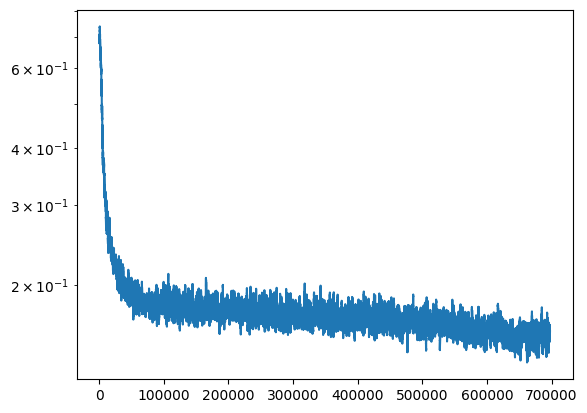

In [9]:
N = 501; plt.semilogy(np.convolve(train_losses,N*[1/N], mode='valid'))

0.6414651870727539


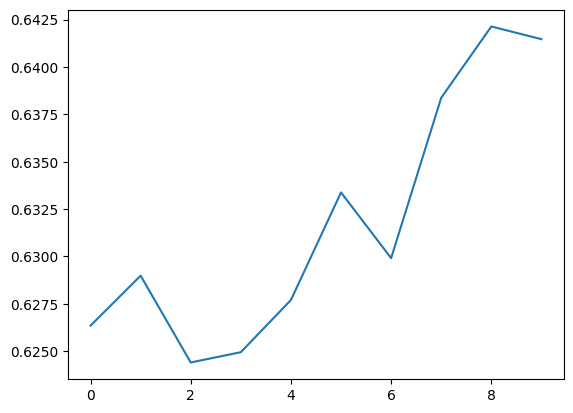

In [10]:
plt.plot(valid_miou)
print(valid_miou[-1])